In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
print("All imports sucessful")

All imports sucessful


In [4]:
ratings = pd.read_csv('../data/ratings.csv')
books = pd.read_csv('../data/books.csv')
tags = pd.read_csv('../data/tags.csv')
book_tags = pd.read_csv('../data/book_tags.csv')
to_read = pd.read_csv('../data/to_read.csv')

print("ratings:", ratings.shape)
print("books:", books.shape)
print("tags:", tags.shape)
print("book_tags:", book_tags.shape)
print("to_read:", to_read.shape)

ratings: (981756, 3)
books: (10000, 23)
tags: (34252, 2)
book_tags: (999912, 3)
to_read: (912705, 2)


In [5]:
ratings.head()

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


In [5]:
books.head()

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [6]:
ratings.describe()

,book_id,user_id,rating
count,981756.000000,981756.000000,981756.000000
mean,4943.275636,25616.759933,3.856534
std,2873.207415,15228.338826,0.983941
min,1.000000,1.000000,1.000000
25%,2457.000000,12372.000000,3.000000
50%,4921.000000,25077.000000,4.000000
75%,7414.000000,38572.000000,5.000000
max,10000.000000,53424.000000,5.000000


In [7]:
ratings['rating'].value_counts().sort_index()

rating
1     19575
2     63231
3    248623
4    357366
5    292961
Name: count, dtype: int64

In [8]:
n_users = ratings['user_id'].nunique()
n_books = ratings['book_id'].nunique()
n_ratings = len(ratings)

sparsity = 1-(n_ratings/(n_users*n_books))

print(f"Number of users: {n_users}")
print(f"Number of books: {n_books}")
print(f"Number of ratings: {n_ratings}")
print(f"Possible user-book combinations: {n_users * n_books:,}")
print(f"Sparsity: {sparsity:.4%}")

Number of users: 53424
Number of books: 10000
Number of ratings: 981756
Possible user-book combinations: 534,240,000
Sparsity: 99.8162%


In [10]:
ratings_per_user = ratings.groupby('user_id')['rating'].count()
ratings_per_book = ratings.groupby('book_id')['rating'].count()

print("Ratings per user:")
print(ratings_per_user.describe())
print("\nRatings per book:")
print(ratings_per_book.describe())

Ratings per user:
count    53424.000000
mean        18.376685
std         26.268690
min          2.000000
25%          3.000000
50%          8.000000
75%         22.000000
max        200.000000
Name: rating, dtype: float64

Ratings per book:
count    10000.000000
mean        98.175600
std          5.690167
min          8.000000
25%         99.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: rating, dtype: float64


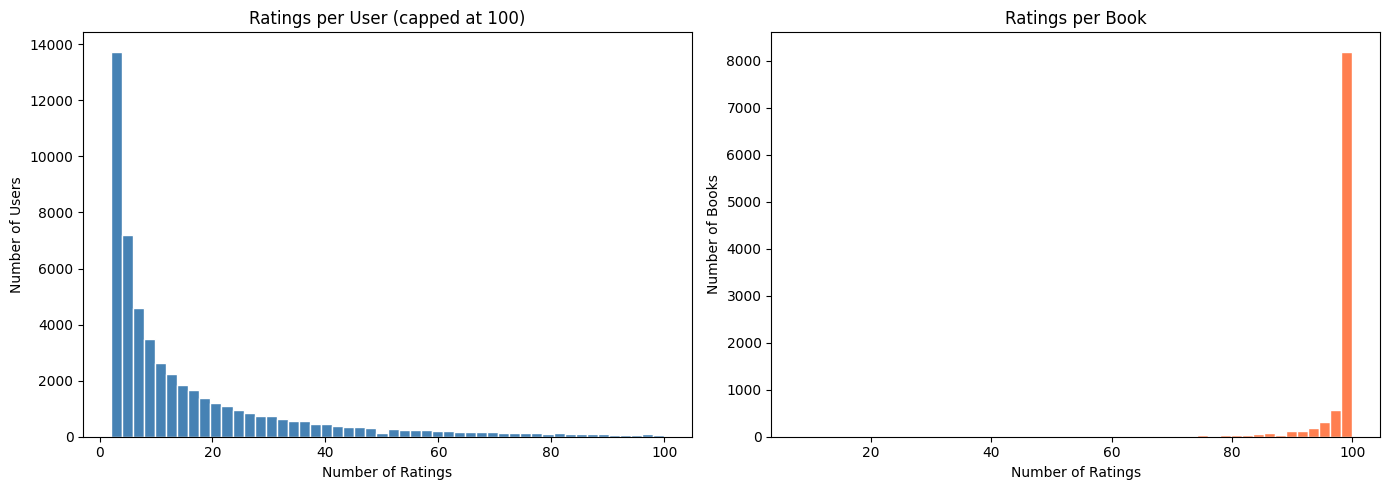

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ratings_per_user[ratings_per_user <= 100], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Ratings per User (capped at 100)')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')

axes[1].hist(ratings_per_book, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Ratings per Book')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Books')

plt.tight_layout()
plt.show()

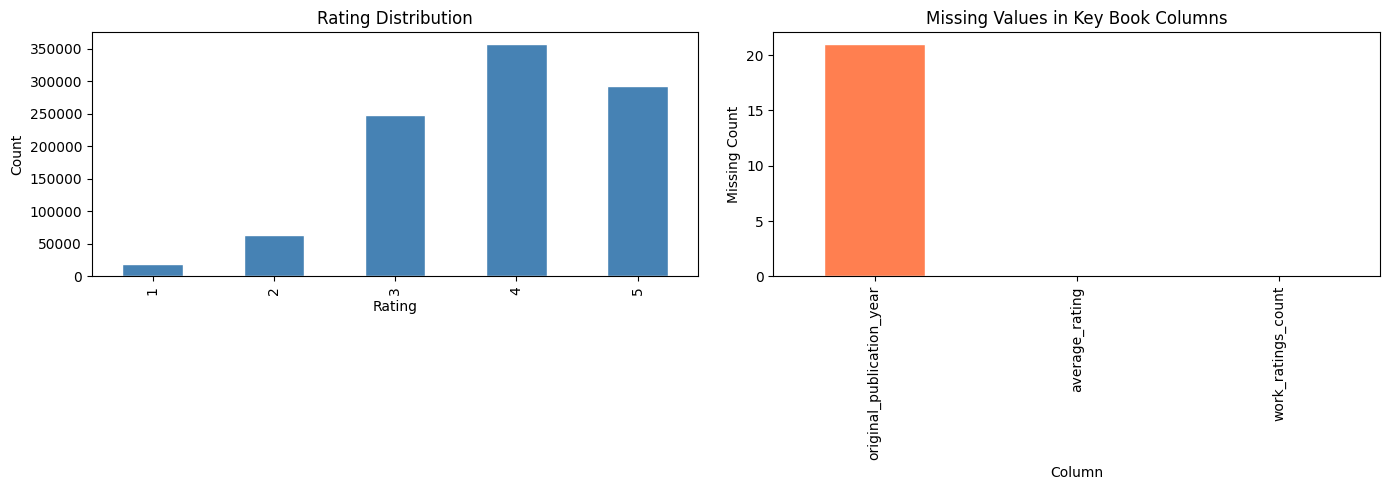

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

books[['original_publication_year', 'average_rating', 'work_ratings_count']].isnull().sum().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Missing Values in Key Book Columns')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Missing Count')

plt.tight_layout()
plt.show()

In [14]:
top_books = ratings.groupby('book_id')['rating'].agg(['count','mean']).reset_index()
top_books = top_books.merge(books[['id','original_title','authors']],left_on='book_id',right_on='id')
top_books = top_books.sort_values('mean',ascending=False)

print("Top 10 highest rated books:")
print(top_books[['original_title','authors','count','mean']].head(10).to_string())

print("\nBottom 10 lowest rated books:")
print(top_books[['original_title','authors','count','mean']].tail(10).to_string())

Top 10 highest rated books:
                                                                               original_title                                     authors  count      mean
7946                                                                                      NaN  Anonymous, Lane T. Dennis, Wayne A. Grudem     89  4.820225
6919                        The Indispensable Calvin and Hobbes: A Calvin and Hobbes Treasury                              Bill Watterson    100  4.780000
5206                                 The Days Are Just Packed: A Calvin and Hobbes Collection                              Bill Watterson    100  4.780000
9565  Attack of the Deranged Mutant Killer Monster Snow Goons: A Calvin and Hobbes Collection                              Bill Watterson     99  4.777778
8945                                                                          دیوان‎‎ [Dīvān]                                       Hafez     93  4.774194
6360                              There's 

# Data Exploration Summary

## Dataset
- 53,424 users, 10,000 books, 981,756 ratings
- Rating scale: 1-5
- Sparsity: 99.82% — most user-book pairs have no interaction

## Key Findings
- Average user has rated 18 books (median 8) — heavy long tail
- Every book has ~100 ratings — dataset was deliberately balanced
- Strong positivity bias — ratings 4 and 5 dominate
- Only 21 missing publication years — data is very clean

## Data Quality Issues
- 2 books have missing titles (NaN) — need to fill from title column
- Comic collections (Calvin and Hobbes) cluster at top — may skew recs
- Blocklist needed for certain titles in API layer

## Decisions for Modelling
- Filter users with fewer than 5 ratings before training
- Use implicit feedback framing (interaction = positive signal)
- Fill missing publication years with median
- Time-aware train/test split to prevent data leakage

## Next Step
- 02_baseline_models.ipynb — popularity model + item-item CF